# Exploratory Data Analysis: Two-Column Click Behavior in Qilin

This notebook presents the exploratory data analysis (EDA) for my MSc thesis on click modeling in two-column search and recommendation interfaces.

The goal of this EDA is to understand how click behavior is distributed across position, row, and column in a two-column layout. In particular, I investigate whether user clicks show evidence of examination bias and whether a one-dimensional rank-based view may be insufficient for this interface.

This notebook uses the recommendation part of the Qilin dataset.

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ds1 = load_dataset("THUIR/Qilin", "recommendation_train")
ds2 = load_dataset("THUIR/Qilin", "recommendation_test")

df1 = ds1["train"].to_pandas()
df2 = ds2["train"].to_pandas()

df = pd.concat([df1, df2], ignore_index=True)

In [5]:
print(df.shape)
print(df.columns)
# df.head()

(94552, 7)
Index(['recent_clicked_note_idxs', 'request_idx', 'session_idx', 'user_idx',
       'query', 'rec_result_details_with_idx', 'rec_results'],
      dtype='str')


## Dataset overview

The recommendation data is stored at the request level. Each row corresponds to a recommendation request and contains a list of recommended items together with interaction information.

For click modeling, the request-level format is not yet suitable. Therefore, I transform the nested recommendation results into an item-level table, where each row corresponds to one displayed item.

This makes it possible to analyze click probability at the level of individual displayed positions.

In [ ]:
df.loc[0, "rec_result_details_with_idx"]

## Transforming the nested results into item-level observations

The column `rec_result_details_with_idx` contains the displayed recommendation results for each request. Each element includes variables such as click and position.

To analyze position effects, I convert this nested structure into a flat table in which each row corresponds to one displayed item. This is the main table used in the remainder of the EDA.

In [8]:
result_df = df[["session_idx", "request_idx", "rec_result_details_with_idx"]].explode("rec_result_details_with_idx")
result_df = result_df[result_df["rec_result_details_with_idx"].notna()].copy()
result_df.head()

,session_idx,request_idx,rec_result_details_with_idx
0,55877,23194,"{'click': 1, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."
0,55877,23194,"{'click': 0, 'collect': 0, 'comment': 0, 'like..."


In [10]:
result_df = result_df.reset_index(drop=True)

details_df = pd.json_normalize(result_df["rec_result_details_with_idx"])

result_df = pd.concat(
    [result_df[["session_idx", "request_idx"]], details_df],
    axis=1
)

result_df.head()

,session_idx,request_idx,click,collect,comment,like,note_idx,page_time,position,request_timestamp,share
0,55877,23194,1,0,0,0,885037,0.0,7,1.732111e+09,0
1,55877,23194,0,0,0,0,738980,0.0,5,1.732111e+09,0
2,55877,23194,0,0,0,0,580177,0.0,6,1.732111e+09,0
3,55877,23194,0,0,0,0,1466260,0.0,8,1.732111e+09,0
4,55877,23194,0,0,0,0,1639858,0.0,9,1.732111e+09,0


In [11]:
print(result_df.columns)
result_df.head()

Index(['session_idx', 'request_idx', 'click', 'collect', 'comment', 'like',
       'note_idx', 'page_time', 'position', 'request_timestamp', 'share'],
      dtype='str')


,session_idx,request_idx,click,collect,comment,like,note_idx,page_time,position,request_timestamp,share
0,55877,23194,1,0,0,0,885037,0.0,7,1.732111e+09,0
1,55877,23194,0,0,0,0,738980,0.0,5,1.732111e+09,0
2,55877,23194,0,0,0,0,580177,0.0,6,1.732111e+09,0
3,55877,23194,0,0,0,0,1466260,0.0,8,1.732111e+09,0
4,55877,23194,0,0,0,0,1639858,0.0,9,1.732111e+09,0


## Selecting variables for the EDA

For this exploratory analysis, I focus on variables that are directly relevant to click behavior and examination bias:

- `session_idx`: identifies the session
- `request_idx`: identifies the recommendation request
- `note_idx`: identifies the item
- `position`: the shown rank/index
- `click`: whether the item was clicked

The analysis later derives `row` and `column` from `position` to represent the two-column layout explicitly.

In [13]:
result_df = result_df[["session_idx", "request_idx", "note_idx", "position", "click"]].copy()
result_df.head()

,session_idx,request_idx,note_idx,position,click
0,55877,23194,885037,7,1
1,55877,23194,738980,5,0
2,55877,23194,580177,6,0
3,55877,23194,1466260,8,0
4,55877,23194,1639858,9,0


In [14]:
print("Minimum position:", result_df["position"].min())
print("Maximum position:", result_df["position"].max())
result_df["position"].value_counts().sort_index().head(10)

Minimum position: 1
Maximum position: 293


position
1     97715
2     98250
3     98013
4     90186
5     52504
6     52650
7     46883
8     45236
9     39585
10    37725
Name: count, dtype: int64

## Constructing row and column from position

The interface is treated as a two-column layout. Therefore, the one-dimensional `position` variable is mapped to:

- `row`: vertical placement
- `column`: horizontal placement

Because the minimum observed position is checked directly in the data, row and column are derived from the observed indexing scheme rather than assumed in advance.

In [17]:
result_df["row"] = (result_df["position"] - 1) // 2
result_df["column"] = (result_df["position"] - 1) % 2

In [18]:
result_df[["position", "row", "column", "click"]].head(20)

,position,row,column,click
0,7,3,0,1
1,5,2,0,0
2,6,2,1,0
3,8,3,1,0
4,9,4,0,0
5,10,4,1,0
6,11,5,0,0
7,12,5,1,0
8,1,0,0,1
9,2,0,1,0


The constructed variables represent the interface layout more directly than a single rank variable.

- `row = 0` contains the first visible row
- `column = 0` and `column = 1` represent the left and right positions within each row

This transformation allows the analysis to test whether click behavior depends not only on vertical rank, but also on horizontal placement.

In [20]:
result_df.isna().sum()

session_idx    0
request_idx    0
note_idx       0
position       0
click          0
row            0
column         0
dtype: int64

In [52]:
clean_df = result_df.dropna(subset=["position", "click", "row", "column"]).copy()

clean_df["position"] = clean_df["position"].astype(int)
clean_df["click"] = clean_df["click"].astype(int)
clean_df["row"] = clean_df["row"].astype(int)
clean_df["column"] = clean_df["column"].astype(int)


counts = clean_df.groupby(["row", "column"]).size().unstack(fill_value=0)

min_count = 50

# keep only rows where both columns have enough observations
valid_rows = counts.index[counts.min(axis=1) >= min_count]

# remove row 0 as in the earlier EDA
valid_rows = valid_rows[valid_rows != 0]

clean_df = clean_df[clean_df["row"].isin(valid_rows)].copy()

print("Rows kept:", len(valid_rows))
print("Shape after final cleaning:", clean_df.shape)

clean_df.head()

Rows kept: 53
Shape after final cleaning: (1241980, 7)


,session_idx,request_idx,note_idx,position,click,row,column
0,55877,23194,885037,7,1,3,0
1,55877,23194,738980,5,0,2,0
2,55877,23194,580177,6,0,2,1
3,55877,23194,1466260,8,0,3,1
4,55877,23194,1639858,9,0,4,0


## Basic sanity checks

Before interpreting click-through rates, I first inspect the size and balance of the cleaned impression-level dataset. This is important because CTR estimates can become unstable when some positions have very few observations.

In [53]:
print("Total rows:", len(clean_df))
print("Unique sessions:", clean_df["session_idx"].nunique())
print("Unique requests:", clean_df["request_idx"].nunique())

clean_df["click"].value_counts(normalize=True)

Total rows: 1241980
Unique sessions: 59887
Unique requests: 94513


click
0    0.785774
1    0.214226
Name: proportion, dtype: float64

In [54]:
clean_df.describe()

,session_idx,request_idx,note_idx,position,click,row,column
count,1.241980e+06,1.241980e+06,1.241980e+06,1.241980e+06,1.241980e+06,1.241980e+06,1.241980e+06
mean,6.260706e+04,4.775557e+04,1.110765e+06,2.134889e+01,2.142257e-01,9.928251e+00,4.923912e-01
std,1.735272e+04,2.759419e+04,4.975465e+05,1.776790e+01,4.102843e-01,8.879770e+00,4.999423e-01
min,3.277000e+04,0.000000e+00,2.941000e+03,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,4.750500e+04,2.380400e+04,7.891080e+05,7.000000e+00,0.000000e+00,3.000000e+00,0.000000e+00
50%,6.255000e+04,4.793500e+04,1.152373e+06,1.600000e+01,0.000000e+00,7.000000e+00,0.000000e+00
75%,7.763400e+04,7.185500e+04,1.511946e+06,3.200000e+01,0.000000e+00,1.500000e+01,1.000000e+00
max,9.267200e+04,9.455100e+04,1.983936e+06,1.080000e+02,1.000000e+00,5.300000e+01,1.000000e+00


## CTR by position

As a baseline view, I compute CTR by linear position. This checks whether standard position bias is present: items shown earlier should receive more clicks.

<Axes: title={'center': 'CTR by Position'}, xlabel='position'>

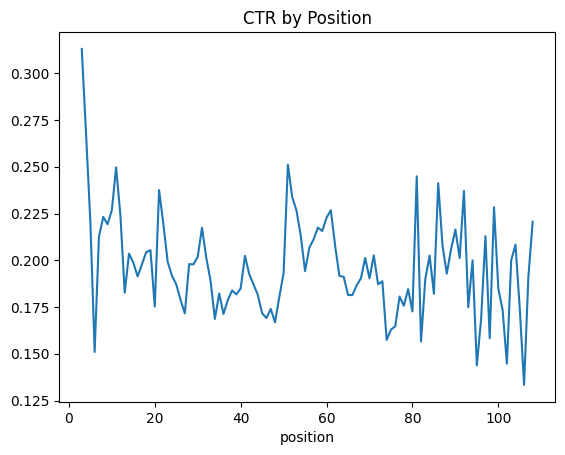

In [55]:
ctr_position = clean_df.groupby("position")["click"].mean()

ctr_position.plot(title="CTR by Position")

## CTR by row

This plot aggregates click behavior at the row level. If CTR decreases with row, this suggests vertical position bias: users are more likely to examine items near the top of the interface.

<Axes: title={'center': 'CTR by Row'}, xlabel='row'>

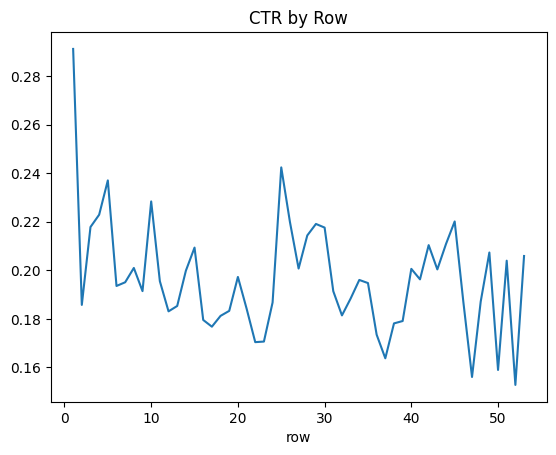

In [56]:
ctr_row = clean_df.groupby("row")["click"].mean()

ctr_row.plot(title="CTR by Row")

## CTR by column

This analysis tests whether horizontal placement matters. If the two columns have different CTR, then a purely one-dimensional ranked-list view may miss part of the examination process.

<Axes: title={'center': 'CTR by Column'}, xlabel='column'>

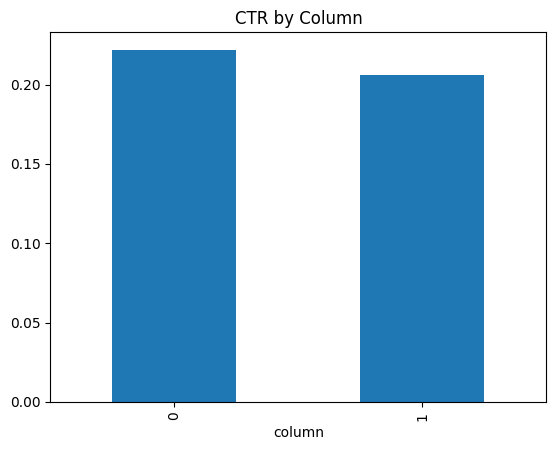

In [57]:
ctr_column = clean_df.groupby("column")["click"].mean()

ctr_column.plot(kind="bar", title="CTR by Column")

## CTR by row and column (line plot)

This plot shows CTR for each row, split by column.

- If both lines decrease with row, that confirms vertical position bias.
- If the two lines differ, that indicates a horizontal column effect.
- If the gap changes across rows, that suggests an interaction between row and column.

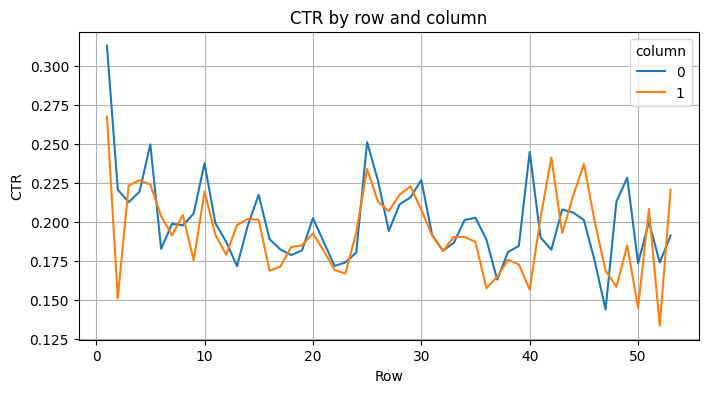

In [58]:
pivot = clean_df.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="mean"
)

plt.figure(figsize=(8,4))
pivot.plot(ax=plt.gca())
plt.xlabel("Row")
plt.ylabel("CTR")
plt.title("CTR by row and column")
plt.grid(True)
plt.show()

In [59]:
ctr_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="mean"
)

ctr_2d

column,0,1
row,,
1,0.313020,0.267425
2,0.220631,0.150940
3,0.212614,0.223207
4,0.219250,0.226693
5,0.249717,0.223944
6,0.182686,0.203554
7,0.198747,0.191381
8,0.197742,0.204356
9,0.205351,0.175255


## CTR heatmap by (row, column)

This heatmap shows CTR for each two-dimensional position in the layout. Under a purely one-dimensional model, both cells within a row would be expected to behave similarly. Visible within-row differences motivate the two-dimensional extension.

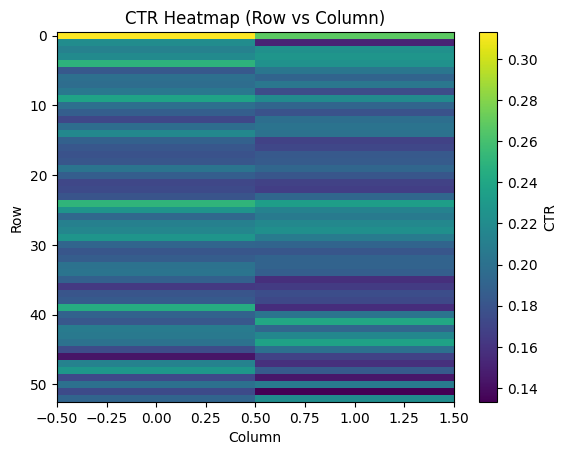

In [60]:
import matplotlib.pyplot as plt

plt.imshow(ctr_2d, aspect="auto")
plt.colorbar(label="CTR")
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("CTR Heatmap (Row vs Column)")
plt.show()

## Exposure by row and column

CTR must be interpreted together with exposure. Positions with few impressions can show unstable CTR estimates, especially in deeper rows.

In [61]:
exposure_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="count"
)

exposure_2d.head(20)

column,0,1
row,,
1,98013,90186
2,52504,52650
3,46883,45236
4,39585,37725
5,34439,33495
6,26488,28700
7,27301,27427
8,26125,24702
9,23321,20125


In [62]:
# Sort by position (top first)
clean_df_sorted = clean_df.sort_values(by=["session_idx", "position"])

# Get first click per session
first_clicks = clean_df_sorted[clean_df_sorted["click"] == 1] \
    .groupby("session_idx") \
    .first()

first_clicks[["row", "column"]].head(20)

,row,column
session_idx,,
32770,1,0
32771,10,0
32772,1,0
32773,1,0
32775,1,1
32777,1,0
32778,1,0
32779,1,1
32781,1,0


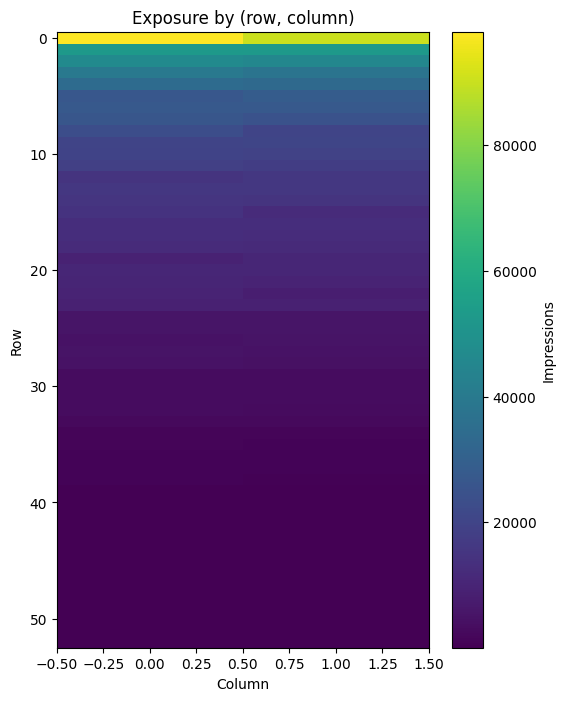

In [63]:
plt.figure(figsize=(6,8))
plt.imshow(exposure_2d, aspect="auto")
plt.colorbar(label="Impressions")
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Exposure by (row, column)")
plt.show()

## Exposure by row

To determine which rows are reliable enough to interpret, I inspect the number of impressions per row. Deep rows may contain too little data for stable CTR estimates.

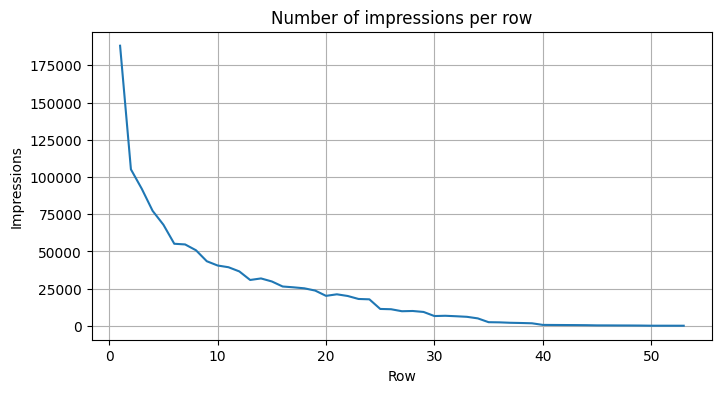

(row
 1     188199
 2     105154
 3      92119
 4      77310
 5      67934
 6      55188
 7      54728
 8      50827
 9      43446
 10     40577
 11     39422
 12     36613
 13     30864
 14     31895
 15     29865
 16     26479
 17     25927
 18     25262
 19     23740
 20     20193
 dtype: int64,
 row
 34    5071
 35    2506
 36    2398
 37    2113
 38    1965
 39    1770
 40     688
 41     642
 42     599
 43     559
 44     498
 45     368
 46     353
 47     314
 48     294
 49     246
 50     151
 51     152
 52     144
 53     136
 dtype: int64)

In [64]:
counts_row = clean_df.groupby("row").size()

plt.figure(figsize=(8,4))
counts_row.plot()
plt.xlabel("Row")
plt.ylabel("Impressions")
plt.title("Number of impressions per row")
plt.grid(True)
plt.show()

counts_row.head(20), counts_row.tail(20)

## First-click analysis

As an exploratory proxy for examination order, I inspect the position of the first click within each request. If first clicks are concentrated in the top-left area, this is consistent with a top-down, left-to-right scanning pattern.

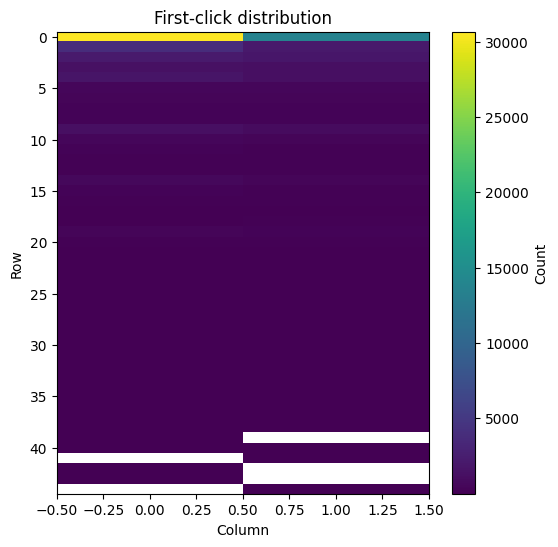

In [65]:
first_clicks = (
    clean_df[clean_df["click"] == 1]
    .sort_values(["session_idx", "request_idx", "position"])
    .groupby(["session_idx", "request_idx"])
    .first()
    .reset_index()
)

first_click_dist = first_clicks.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="count"
)

plt.figure(figsize=(6,6))
plt.imshow(first_click_dist, aspect="auto")
plt.colorbar(label="Count")
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("First-click distribution")
plt.show()

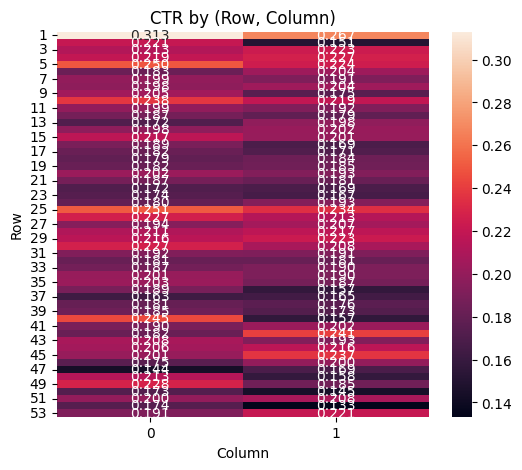

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

ctr_grid = clean_df.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="mean"
)

plt.figure(figsize=(6, 5))
sns.heatmap(ctr_grid, annot=True, fmt=".3f")
plt.title("CTR by (Row, Column)")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

In [67]:
print(len(clean_df))
print(clean_df["session_idx"].nunique())
print(clean_df["request_idx"].nunique())
print(clean_df["click"].mean())

1241980
59887
94513
0.21422567191098085


In [68]:
first_click_share = (
    first_clicks.groupby(["row", "column"]).size() /
    len(first_clicks)
)
print(first_click_share)

row  column
1    0         0.428945
     1         0.190128
2    0         0.054862
     1         0.029278
3    0         0.030622
                 ...   
41   1         0.000014
42   1         0.000042
43   0         0.000014
44   0         0.000028
49   1         0.000014
Length: 85, dtype: float64


The analysis shows a clear position bias, where items at higher rows receive higher click-through rates. This confirms that ranking position strongly influences user interactions.

In addition, differences between columns are observed, suggesting that the layout structure also affects click behavior. The combination of row and column further indicates that clicks are not determined by a single linear ranking, but depend on the two-dimensional placement of items.


1.	Is a 2D extension of PBM enough as my main model?”
2.	Is comparing it to a standard 1D PBM baseline sufficient?”
3.	Should I keep the model simple (only row & column), given I only have click data?

P(click) = f(row, column)

Assume behavioral assumptions that I cannot verify?
Since I only observe clicks and not examination behavior, I’m planning to model click probability as a function of row and column only. Do you think this is sufficient, or do you expect a model with stronger behavioral assumptions?

Baselines

Two one-dimensional click models are used as baselines:

•	Position-Based Model (PBM)
PBM assumes that click probability depends on position-based examination and item relevance. It serves as a strong and widely used baseline, but treats the interface as a single ranked list and cannot distinguish between columns. This makes it particularly suitable for evaluating whether modeling the column dimension adds value.

•	Dynamic Bayesian Network (DBN)
DBN extends PBM by incorporating sequential dependencies, allowing examination to depend on previous interactions. It represents a stronger baseline, capturing more complex user behavior while still operating in a one-dimensional setting.

Using both PBM and DBN ensures that improvements of the proposed model are not merely due to increased model complexity, but specifically due to incorporating the two-dimensional layout.

⸻

Evaluation Metrics

Models are evaluated using the following metrics:

•	Log-Likelihood (LL)
Measures how well predicted click probabilities match observed clicks. It is the standard objective for click models and directly evaluates probabilistic fit.

•	Perplexity
A normalized version of log-likelihood that accounts for dataset size. Lower perplexity indicates better predictive performance and allows for easier comparison across models.

•	Accuracy
Measures the proportion of correctly predicted clicks after thresholding probabilities. While less informative due to class imbalance, it provides a simple sanity check alongside probabilistic metrics.

These metrics are chosen because they directly assess the quality of predicted click probabilities, which is the primary goal of click modeling.




What DBN adds

The Dynamic Bayesian Network (DBN) is:
	•	still 1D (no column awareness)
	•	but more expressive than PBM

It models:
	•	dependency between positions
	•	sequential behavior

So it’s a stronger baseline